In [35]:
# general
import numpy as np
from numpy.random import PCG64, SeedSequence
import pandas as pd
import verde as vd
import xarray as xr
import skgstat as skg
from skgstat import models
import gstatsim as gsm
from scipy.interpolate import RBFInterpolator
from scipy.stats import qmc
from sklearn.preprocessing import QuantileTransformer
from tqdm.auto import tqdm
from numba import njit, prange
from numba_progress import ProgressBar

# plotting
import matplotlib.pyplot as plt
import cmocean
from cmcrameri import cm

# io
from tqdm.auto import tqdm
import os
from pathlib import Path
import time
import numbers
import warnings

import sys
sys.path.append('../src')

import gstatsim_custom as gsim

from gstatsim_custom import interpolate
import importlib
importlib.reload(interpolate)

<module 'gstatsim_custom.interpolate' from 'G:\\antarctic_iceshelves\\random\\../src\\gstatsim_custom\\interpolate.py'>

In [5]:
ds = xr.open_dataset(Path('G:/bedmap_interpolation/processed_data/bedmap3_mod_1000.nc'))
ds = ds.coarsen(x=5, y=5, boundary='trim').median()

# exposed_rock_cond = np.full(ds.thick_cond.shape, np.nan)
# exposed_rock_cond[ds.mask == 4] = True
thick_cond = np.where(ds.mask == 4, 0, ds.thick_cond.values)
#ground_ice_msk = ds.mask==1

bed_cond = ds.surface_topography.values - thick_cond
ice_rock_msk = (ds.mask == 1) | (ds.mask == 4) | (ds.mask == 2)
bed_cond = np.where(ice_rock_msk, bed_cond, np.nan)
xx, yy = np.meshgrid(ds.x, ds.y)

cond_msk = ~np.isnan(bed_cond)
#cond_msk = np.where(
x_cond = xx[cond_msk]
y_cond = yy[cond_msk]
data_cond = bed_cond[cond_msk]
trend = ds.trend.values

res_cond = bed_cond - trend

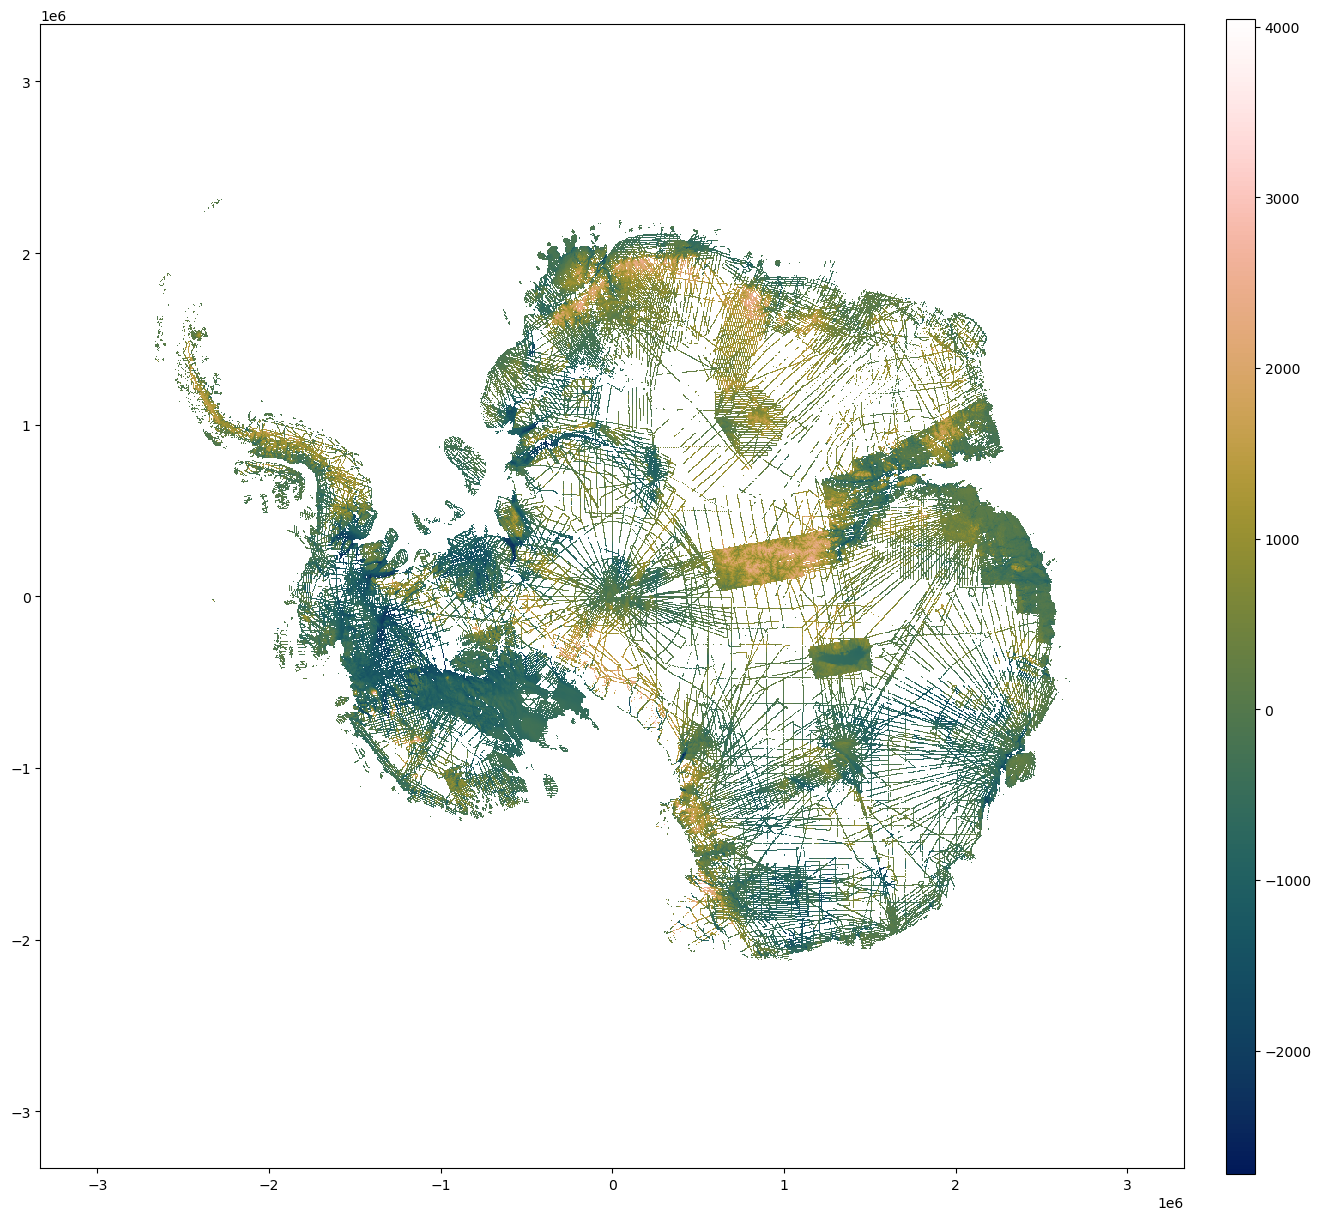

In [14]:
plt.figure(figsize=(18,15))
plt.pcolormesh(ds.x, ds.y, bed_cond, cmap=cm.batlowW)
plt.axis('scaled')
plt.colorbar(pad=0.03, aspect=40)
plt.show()

In [16]:
def spline_interp_msk(points, values, xx, yy, mask, damping):
    sp = vd.Spline(damping=damping)
    sp.fit((points[:,0], points[:,1]), values)
    preds = sp.predict((xx[mask], yy[mask]))
    grid = np.full(xx.shape, np.nan)
    np.place(grid, mask, preds)
    return grid

In [17]:
cond_coords = np.array([x_cond[::1000], y_cond[::1000]]).T
trend = spline_interp_msk(cond_coords, data_cond[::1000], xx, yy, ice_rock_msk, damping=1e-5)

res_cond = bed_cond - trend

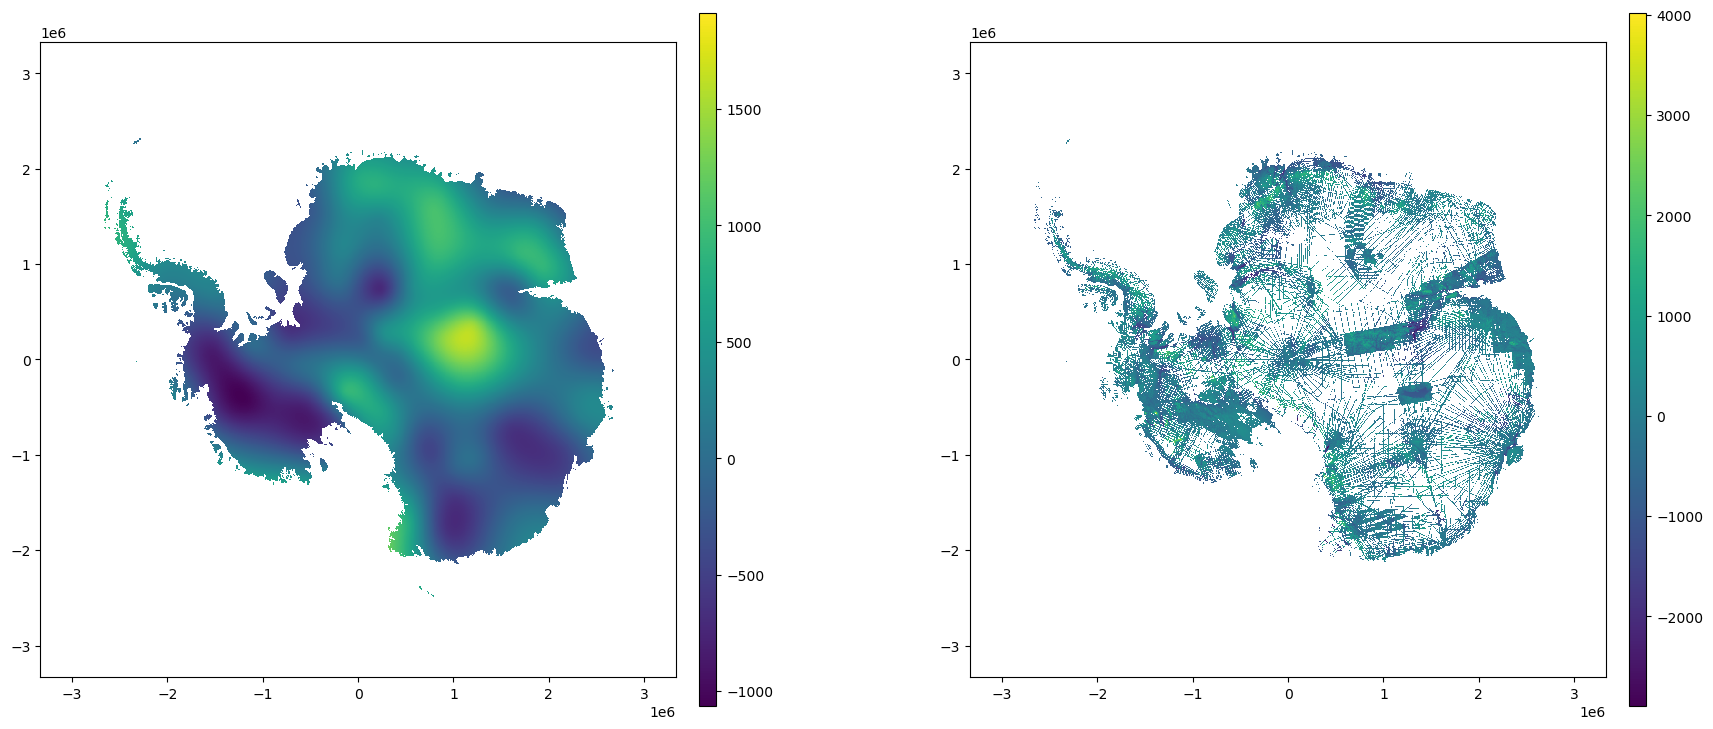

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(22,9))
ax = axs[0]
im = ax.pcolormesh(ds.x, ds.y, trend)
ax.axis('scaled')
plt.colorbar(im, pad=0.03, aspect=40)

ax = axs[1]
im = ax.pcolormesh(ds.x, ds.y, res_cond)
ax.axis('scaled')
plt.colorbar(im, pad=0.03, aspect=40)
plt.show()

# IBCSO

In [47]:
bath = xr.open_dataset(Path('D:/IBCSO_v2_allfiles/IBCSO_v2_bed.nc'))
bath

<xarray.Dataset> Size: 1GB
Dimensions:              (x: 19200, y: 19200)
Coordinates:
  * x                    (x) float64 154kB -4.8e+06 -4.799e+06 ... 4.8e+06
  * y                    (y) float64 154kB -4.8e+06 -4.799e+06 ... 4.8e+06
Data variables:
    polar_stereographic  |S1 1B ...
    z                    (y, x) float32 1GB ...
Attributes:
    Conventions:      CF-1.5
    title:            International Bathymetric Chart of the Southern Ocean (...
    institution:      Alfred Wegener Institute Helmholtz Centre for Polar and...
    contact:          Dr. Boris Dorschel, IBCSO@awi.de,southern-ocean@seabed2...
    comment:          The International Bathymetric Chart of the Southern Oce...
    doi:              https://doi.pangaea.de/10.1594/PANGAEA.937574
    webpage:          www.ibcso.org
    IBCSO_version:    2.0
    doi_publication:  https://doi.org/10.1038/s41597-022-01366-7

In [34]:
bath.x.values[1]-bath.x.values[0]

np.float64(500.0)

In [33]:
tid = xr.open_dataset(Path('D:/IBCSO_v2_allfiles/IBCSO_v2_tid.nc'))
tid

<xarray.Dataset> Size: 1GB
Dimensions:              (x: 19200, y: 19200)
Coordinates:
  * x                    (x) float64 154kB -4.8e+06 -4.799e+06 ... 4.8e+06
  * y                    (y) float64 154kB -4.8e+06 -4.799e+06 ... 4.8e+06
Data variables:
    polar_stereographic  |S1 1B ...
    tid                  (y, x) float32 1GB ...
Attributes:
    Conventions:      CF-1.5
    title:            International Bathymetric Chart of the Southern Ocean (...
    institution:      Alfred Wegener Institute Helmholtz Centre for Polar and...
    contact:          Dr. Boris Dorschel, IBCSO@awi.de,southern-ocean@seabed2...
    comment:          The International Bathymetric Chart of the Southern Oce...
    doi:              https://doi.pangaea.de/10.1594/PANGAEA.937574
    webpage:          www.ibcso.org
    IBCSO_version:    2.0
    doi_publication:  https://doi.org/10.1038/s41597-022-01366-7

In [39]:
bath.polar_stereographic

<xarray.DataArray 'polar_stereographic' ()> Size: 1B
[1 values with dtype=|S1]
Attributes:
    grid_mapping_name:                      polar_stereographic
    straight_vertical_longitude_from_pole:  0.0
    false_easting:                          0.0
    false_northing:                         0.0
    latitude_of_projection_origin:          -90.0
    standard_parallel:                      -65.0
    long_name:                              CRS definition
    longitude_of_prime_meridian:            0.0
    semi_major_axis:                        6378137.0
    inverse_flattening:                     298.257223563
    spatial_ref:                            PROJCS["WGS 84 / IBCSO Polar Ster...
    GeoTransform:                           -4800000 500 0 4800000 0 -500

In [37]:
from pyproj import Transformer, CRS

In [38]:
CRS(3031)

<Projected CRS: EPSG:3031>
Name: WGS 84 / Antarctic Polar Stereographic
Axis Info [cartesian]:
- E[north]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Antarctica.
- bounds: (-180.0, -90.0, 180.0, -60.0)
Coordinate Operation:
- name: Antarctic Polar Stereographic
- method: Polar Stereographic (variant B)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [40]:
CRS(9354)

<Projected CRS: EPSG:9354>
Name: WGS 84 / IBCSO Polar Stereographic
Axis Info [cartesian]:
- X[north]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Southern hemisphere - south of 50°S onshore and offshore, including Antarctica.
- bounds: (-180.0, -90.0, 180.0, -50.0)
Coordinate Operation:
- name: IBCSO Polar Stereographic
- method: Polar Stereographic (variant B)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [41]:
xx_ibcso, yy_ibcso = np.meshgrid(bath.x, bath.y)

transformer = Transformer.from_crs(9354, 3031)
xx_ant, yy_ant = transformer.transform(xx_ibcso, yy_ibcso)

In [49]:
@njit(parallel=True)
def block_reduce_jit(xx, bins, thickness, progress_proxy):
    
    counts = np.zeros(xx.shape)
    mean = np.full(xx.shape, np.nan)
    median = np.full(xx.shape, np.nan)
    stdev = np.full(xx.shape, np.nan)
    median_partial = np.full(xx.shape, np.nan)
    
    xb_uniq = np.unique(bins[:,0])
    yb_uniq = np.unique(bins[:,1])
    
    for i in prange(xb_uniq.size):
        xbin = xb_uniq[i]
        inds1 = bins[:,0]==xbin
        bins1 = bins[inds1,:]
        thick1 = thickness[inds1]
        # rands1 = rands[inds1]
        for j in range(yb_uniq.size):
            ybin = yb_uniq[j]
            inds2 = bins1[:,1]==ybin
            thick2 = thick1[inds2]
            # rands2 = rands1[inds2]
            
            count = thick2.size
            if count > 0:
                counts[ybin,xbin] = count
                mean[ybin,xbin] = np.mean(thick2)
                median[ybin,xbin] = np.nanquantile(thick2, 0.5)
                stdev[ybin,xbin] = np.std(thick2)
                # if count > 1:
                #     sample = thick2[rands2 > 0.5]
                #     if sample.size==0:
                #         median_partial[ybin,xbin] = np.nanquantile(thick2, 0.5)
                #     else:
                #         median_partial[ybin,xbin] = np.nanquantile(sample, 0.5)
                # else:
                #     median_partial[ybin,xbin] = thick2[0]
        progress_proxy.update(1)
        
    return counts, mean, median, stdev

In [50]:
xx, yy = np.meshgrid(ds.x, ds.y)

### Custom block reduction
xbin_edges = ds.x.values - 250
xbin_edges = np.append(xbin_edges, ds.x.values[-1]+250)

ybin_edges = ds.y.values - 250
ybin_edges = np.append(ybin_edges, ds.y.values[-1]-750)

xbins = np.digitize(xx_ant.flatten(), xbin_edges)
ybins = np.digitize(yy_ant.flatten(), ybin_edges)

# do block reduction
bins = np.stack([xbins, ybins]).T
bathy = bath.z.values

print('doing block reduction of bathy')
with ProgressBar(total=np.unique(xbins).size) as progress:
    result_bathy = block_reduce_jit(xx, bins, bathy, progress)

bins = np.stack([xbins, ybins]).T
tid = tid.tid.values

print('doing block reduction of tid')
with ProgressBar(total=np.unique(xbins).size) as progress:
    result_tid = block_reduce_jit(xx, bins, tid, progress)

doing block reduction of bathy


  0%|          | 0/1335 [00:00<?, ?it/s]

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1mNameError: name 'rands' is not defined[0m
[0m[1mDuring: Pass nopython_type_inference[0m